# EJD-UMA-002 v1.0 — Tree Edit Distance y Proyeccion MDS sobre Arboles Federados
## Ejercicio Doctoral — Programa de Doctorado en Tecnologias Informaticas — Universidad de Malaga

| Campo | Detalle |
|-------|---------|
| **Codigo** | EJD-UMA-002 |
| **Version** | 1.0 |
| **Referencia** | Ejercicio propuesto por Prof. E. Lopez Rubio — respuesta al EJD-UMA-001 |
| **Autor** | Edgar O. Herrera Logrono · M.Sc. Inteligencia Artificial — VIU Espana |
| **Directores** | Prof. Ezequiel Lopez Rubio · Prof. Juan Miguel Ortiz de Lazcano — UMA |
| **Fecha** | Marzo 2026 |

---
## Contexto del ejercicio

Al revisar el ejercicio EJD-UMA-001, el Prof. Lopez Rubio propuso calcular una medida de distancia estructural entre los arboles de decision aprendidos durante el ciclo federado. La tecnica indicada es la Tree Edit Distance (TED), que cuantifica el numero minimo de operaciones elementales necesarias para transformar un arbol en otro. Con la matriz de distancias obtenida, se aplica Multidimensional Scaling (MDS) para proyectar los arboles en un plano. Cada arbol se representa con un color segun el nodo federado de origen y con un marcador segun el quintil de F1-Score individual en validacion.

El objetivo es verificar si la distribucion espacial revela algun patron aprovechable para mejorar el mecanismo de agregacion del sistema federado.

---
## Parametros configurables

Ajuste los valores de esta seccion antes de ejecutar **Runtime > Run all**. Todos los calculos y conclusiones se generan automaticamente en funcion de estos parametros.

In [1]:
# ══════════════════════════════════════════════════════════════════════
# PARAMETROS CONFIGURABLES — modifique aqui antes de ejecutar Run all
# ══════════════════════════════════════════════════════════════════════

N_ARBOLES_POR_NODO = 50    # Arboles a entrenar por nodo federado (sugerido: 25, 50, 100)
N_ARBOLES_MUESTRA  = 20    # Arboles por nodo para calculo TED (10-30)
                            # 20 arboles/nodo => 60 totales, 1.770 pares, ~10 min en Colab
                            # 30 arboles/nodo => 90 totales, 3.915 pares, ~25 min en Colab
SEMILLA            = 42    # Semilla de reproducibilidad
LIMITE_PROFUNDIDAD = 6     # Profundidad maxima de conversion arbol->zss
LIMITE_NODOS_ZSS   = 200   # Nodos maximos por arbol en conversion zss

# ══════════════════════════════════════════════════════════════════════
print("Parametros configurados:")
print(f"  Arboles por nodo (entrenamiento) : {N_ARBOLES_POR_NODO}")
print(f"  Arboles por nodo (muestra TED)   : {N_ARBOLES_MUESTRA}")
print(f"  Total arboles para TED           : {N_ARBOLES_MUESTRA * 3}")
print(f"  Total pares a calcular           : {(N_ARBOLES_MUESTRA*3)*(N_ARBOLES_MUESTRA*3-1)//2:,}")
print(f"  Semilla                          : {SEMILLA}")
print(f"  Limite profundidad zss           : {LIMITE_PROFUNDIDAD}")
print(f"  Limite nodos zss                 : {LIMITE_NODOS_ZSS}")
print()
print("[ OK ] Parametros listos")

Parametros configurados:
  Arboles por nodo (entrenamiento) : 50
  Arboles por nodo (muestra TED)   : 20
  Total arboles para TED           : 60
  Total pares a calcular           : 1,770
  Semilla                          : 42
  Limite profundidad zss           : 6
  Limite nodos zss                 : 200

[ OK ] Parametros listos


---
## Seccion 1 — Preparacion del entorno

In [2]:
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

!pip install -q zss
!pip install -q --only-binary=:all: scikit-learn pandas numpy matplotlib seaborn scipy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from sklearn.manifold import MDS
from sklearn.preprocessing import StandardScaler
from scipy.stats import spearmanr
from matplotlib.patches import Ellipse
from time import time
import zss, os

np.random.seed(SEMILLA)
os.makedirs("resultados_ted", exist_ok=True)

print("[ OK ] Entorno listo — EJD-UMA-002 v1.0")
print(f"  scikit-learn : {__import__('sklearn').__version__}")
print(f"  numpy        : {np.__version__}")

  Preparing metadata (setup.py) ... done
[ OK ] Entorno listo — EJD-UMA-002 v1.0
  scikit-learn : 1.6.1
  numpy        : 2.0.2


---
## Seccion 2 — Carga de datos NSL-KDD

In [3]:
nombres_columnas = [
    "duracion","tipo_protocolo","servicio","bandera","bytes_origen","bytes_destino",
    "tierra","fragmento_incorrecto","urgente","caliente","intentos_login_fallidos",
    "conectado","comprometidos","shell_root","intento_su","num_root",
    "creaciones_archivo","num_shells","archivos_acceso","cmds_salida",
    "login_host","login_invitado","conteo","conteo_srv","tasa_error_s",
    "tasa_error_s_srv","tasa_error_r","tasa_error_r_srv","tasa_mismo_srv",
    "tasa_diff_srv","tasa_diff_host_srv","conteo_host_dst","conteo_srv_host_dst",
    "tasa_mismo_srv_host","tasa_diff_srv_host","tasa_mismo_puerto_src",
    "tasa_diff_host_srv_dst","tasa_error_s_host","tasa_error_s_srv_host",
    "tasa_error_r_host","tasa_error_r_srv_host","tipo_ataque"
]

def cargar_nslkdd():
    url = "https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTrain+.txt"
    try:
        nombres = nombres_columnas + ["dificultad"]
        datos = pd.read_csv(url, header=None, names=nombres)
        datos = datos.drop(columns=["dificultad"])
        print(f"  {len(datos):,} registros cargados.")
        return datos
    except Exception as e:
        print(f"  Fuente no disponible. Generando datos sinteticos...")
        n = 8000
        cols_num = [c for c in nombres_columnas
                    if c not in ["tipo_protocolo","servicio","bandera","tipo_ataque"]]
        d = {}
        for col in cols_num:
            if col in ["bytes_origen","bytes_destino","duracion"]:
                d[col] = np.random.exponential(500,n).astype(int)
            elif "tasa" in col:
                d[col] = np.random.uniform(0,1,n)
            else:
                d[col] = np.random.randint(0,5,n)
        d["tipo_protocolo"] = np.random.choice(["tcp","udp","icmp"],n)
        d["servicio"]       = np.random.choice(["http","ftp","smtp","ssh","privado"],n)
        d["bandera"]        = np.random.choice(["SF","S0","REJ","RSTO"],n,p=[0.6,0.2,0.1,0.1])
        etiq = (["normal"]*int(n*0.52)+["neptune"]*int(n*0.25)+
                ["smurf"]*int(n*0.13)+["portsweep"]*int(n*0.10))
        while len(etiq) < n: etiq.append("normal")
        d["tipo_ataque"] = np.random.permutation(etiq[:n])
        return pd.DataFrame(d)

print("Cargando NSL-KDD...")
datos_brutos = cargar_nslkdd()
datos_brutos["etiqueta"] = datos_brutos["tipo_ataque"].apply(
    lambda x: 0 if str(x).strip().rstrip(".") == "normal" else 1
)
datos_brutos = datos_brutos.drop(columns=["tipo_ataque"])

n_muestra = min(2000, datos_brutos["etiqueta"].value_counts().min())
datos = pd.concat([
    datos_brutos[datos_brutos["etiqueta"]==0].sample(n_muestra, random_state=SEMILLA),
    datos_brutos[datos_brutos["etiqueta"]==1].sample(n_muestra, random_state=SEMILLA)
]).sample(frac=1, random_state=SEMILLA).reset_index(drop=True)

cols_cat  = ["tipo_protocolo","servicio","bandera"]
datos_enc = pd.get_dummies(datos, columns=cols_cat, drop_first=True)
variables_X = datos_enc.drop("etiqueta", axis=1)
variable_y  = datos_enc["etiqueta"]

X_entreno, X_prueba, y_entreno, y_prueba = train_test_split(
    variables_X, variable_y, test_size=0.25, random_state=SEMILLA, stratify=variable_y
)
escalador    = StandardScaler()
X_entr_esc   = pd.DataFrame(escalador.fit_transform(X_entreno), columns=variables_X.columns)
X_prueba_esc = pd.DataFrame(escalador.transform(X_prueba),      columns=variables_X.columns)

n_por_nodo    = len(X_entr_esc) // 3
nodos_X       = [X_entr_esc.iloc[i*n_por_nodo:(i+1)*n_por_nodo] for i in range(3)]
nodos_y       = [y_entreno.iloc[i*n_por_nodo:(i+1)*n_por_nodo]  for i in range(3)]
nombres_nodos = ["Financiero","Salud","Gobierno"]

print("[ OK ] Datos cargados")
print(f"  Entrenamiento: {len(X_entr_esc):,} | Prueba: {len(X_prueba_esc):,} | Variables: {variables_X.shape[1]}")

Cargando NSL-KDD...
  125,973 registros cargados.
[ OK ] Datos cargados
  Entrenamiento: 3,000 | Prueba: 1,000 | Variables: 109


---
## Seccion 3 — Entrenamiento y seleccion estratificada de arboles

Se entrena un bosque por nodo y se seleccionan arboles estratificados por quintil de F1-Score individual, de forma que todos los niveles de rendimiento esten representados en la muestra para el calculo TED.

In [4]:
print("Entrenando y seleccionando arboles por nodo...")
print("-" * 48)

datos_por_nodo = {}

for nombre, Xn, yn in zip(nombres_nodos, nodos_X, nodos_y):
    bosque = RandomForestClassifier(
        n_estimators=N_ARBOLES_POR_NODO,
        max_features="sqrt",
        min_samples_leaf=2,
        random_state=SEMILLA,
        n_jobs=-1
    )
    bosque.fit(Xn, yn)

    f1_individuales = []
    for arbol in bosque.estimators_:
        pred = arbol.predict(X_prueba_esc)
        f1   = f1_score(y_prueba, pred, average="weighted", zero_division=0)
        f1_individuales.append(f1)

    arreglo_f1 = np.array(f1_individuales)
    quintiles  = pd.qcut(arreglo_f1, q=5, labels=False, duplicates="drop")

    indices_elegidos = []
    for q in range(5):
        idx_q = np.where(quintiles == q)[0]
        n_sel = min(4, len(idx_q))
        if n_sel > 0:
            seleccion = np.random.choice(idx_q, n_sel, replace=False)
            indices_elegidos.extend(seleccion.tolist())
        if len(indices_elegidos) >= N_ARBOLES_MUESTRA:
            break
    indices_elegidos = indices_elegidos[:N_ARBOLES_MUESTRA]

    datos_por_nodo[nombre] = {
        "arboles"  : [bosque.estimators_[i] for i in indices_elegidos],
        "f1_scores": [f1_individuales[i]    for i in indices_elegidos],
        "quintiles": [int(quintiles[i]) if quintiles[i] is not None else 2
                      for i in indices_elegidos]
    }
    f1_medio = np.mean([f1_individuales[i] for i in indices_elegidos])
    print(f"  {nombre}: {len(indices_elegidos)} arboles | F1 medio muestral: {f1_medio:.4f}")

total_arboles = sum(len(v["arboles"]) for v in datos_por_nodo.values())
total_pares   = total_arboles * (total_arboles - 1) // 2
print()
print(f"  Total arboles: {total_arboles} | Total pares: {total_pares:,}")
print()
print("[ OK ] Arboles entrenados y seleccionados")

Entrenando y seleccionando arboles por nodo...
------------------------------------------------
  Financiero: 20 arboles | F1 medio muestral: 0.9606
  Salud: 20 arboles | F1 medio muestral: 0.9600
  Gobierno: 20 arboles | F1 medio muestral: 0.9528

  Total arboles: 60 | Total pares: 1,770

[ OK ] Arboles entrenados y seleccionados


---
## Seccion 4 — Conversion a formato zss y calculo de la matriz TED

Los nodos internos se etiquetan con la variable de division y el umbral. Las hojas con la clase predicha. Para arboles que superen los limites configurados, la conversion se detiene en ese punto — limitacion declarada.

In [5]:
from zss import Node, simple_distance

def convertir_arbol_a_zss(arbol, nombres_vars, id_nodo=0, profundidad=0, contador=None):
    if contador is None:
        contador = [0]
    estructura = arbol.tree_
    contador[0] += 1
    if (estructura.feature[id_nodo] < 0 or
            contador[0] > LIMITE_NODOS_ZSS or
            profundidad > LIMITE_PROFUNDIDAD):
        clase = int(np.argmax(estructura.value[id_nodo][0]))
        return Node(f"hoja_{clase}")
    nombre_var  = nombres_vars[estructura.feature[id_nodo]]
    umbral      = round(estructura.threshold[id_nodo], 2)
    nodo_actual = Node(f"{nombre_var}<={umbral}")
    nodo_actual.addkid(convertir_arbol_a_zss(arbol, nombres_vars,
                       estructura.children_left[id_nodo], profundidad+1, contador))
    nodo_actual.addkid(convertir_arbol_a_zss(arbol, nombres_vars,
                       estructura.children_right[id_nodo], profundidad+1, contador))
    return nodo_actual

print("Convirtiendo arboles a formato zss...")
lista_arboles_zss = []
lista_nodos       = []
lista_f1          = []
lista_quintiles   = []
nombres_variables = list(X_prueba_esc.columns)

for nombre in nombres_nodos:
    d = datos_por_nodo[nombre]
    for arbol, f1, quintil in zip(d["arboles"], d["f1_scores"], d["quintiles"]):
        lista_arboles_zss.append(convertir_arbol_a_zss(arbol, nombres_variables))
        lista_nodos.append(nombre)
        lista_f1.append(f1)
        lista_quintiles.append(quintil)

print(f"  {len(lista_arboles_zss)} arboles convertidos")
print()
print("Calculando matriz TED (puede tardar 5-15 minutos)...")
print("-" * 50)

num_arboles       = len(lista_arboles_zss)
matriz_distancias = np.zeros((num_arboles, num_arboles))
tiempo_inicio     = time()

for i in range(num_arboles):
    for j in range(i+1, num_arboles):
        d = simple_distance(lista_arboles_zss[i], lista_arboles_zss[j])
        matriz_distancias[i,j] = d
        matriz_distancias[j,i] = d
    if (i+1) % 10 == 0:
        t = time() - tiempo_inicio
        r = t/(i+1)*(num_arboles-i-1)
        print(f"  Arbol {i+1:3d}/{num_arboles} | Transcurrido: {t:.0f}s | Restante: {r:.0f}s")

vals_pos = matriz_distancias[matriz_distancias > 0]
print()
print(f"  Distancia minima: {vals_pos.min():.1f}")
print(f"  Distancia maxima: {matriz_distancias.max():.1f}")
print(f"  Distancia media : {vals_pos.mean():.1f}")
print()
print("[ OK ] Matriz TED calculada")

Convirtiendo arboles a formato zss...
  60 arboles convertidos

Calculando matriz TED (puede tardar 5-15 minutos)...
--------------------------------------------------
  Arbol  10/60 | Transcurrido: 106s | Restante: 531s
  Arbol  20/60 | Transcurrido: 181s | Restante: 361s
  Arbol  30/60 | Transcurrido: 238s | Restante: 238s
  Arbol  40/60 | Transcurrido: 276s | Restante: 138s
  Arbol  50/60 | Transcurrido: 299s | Restante: 60s
  Arbol  60/60 | Transcurrido: 306s | Restante: 0s

  Distancia minima: 367.0
  Distancia maxima: 940.0
  Distancia media : 620.3

[ OK ] Matriz TED calculada


---
## Seccion 5 — Proyeccion MDS y visualizacion (Figura 1)

El Stress MDS normalizado indica la calidad de la representacion: menor de 0.10 es bueno, entre 0.10 y 0.20 es aceptable, mayor de 0.20 indica que la proyeccion 2D pierde fidelidad respecto a las distancias originales.

Calculando proyeccion MDS...
  Stress MDS (normalizado): 0.2843 — representacion limitada: las distancias 2D no capturan bien la variabilidad original



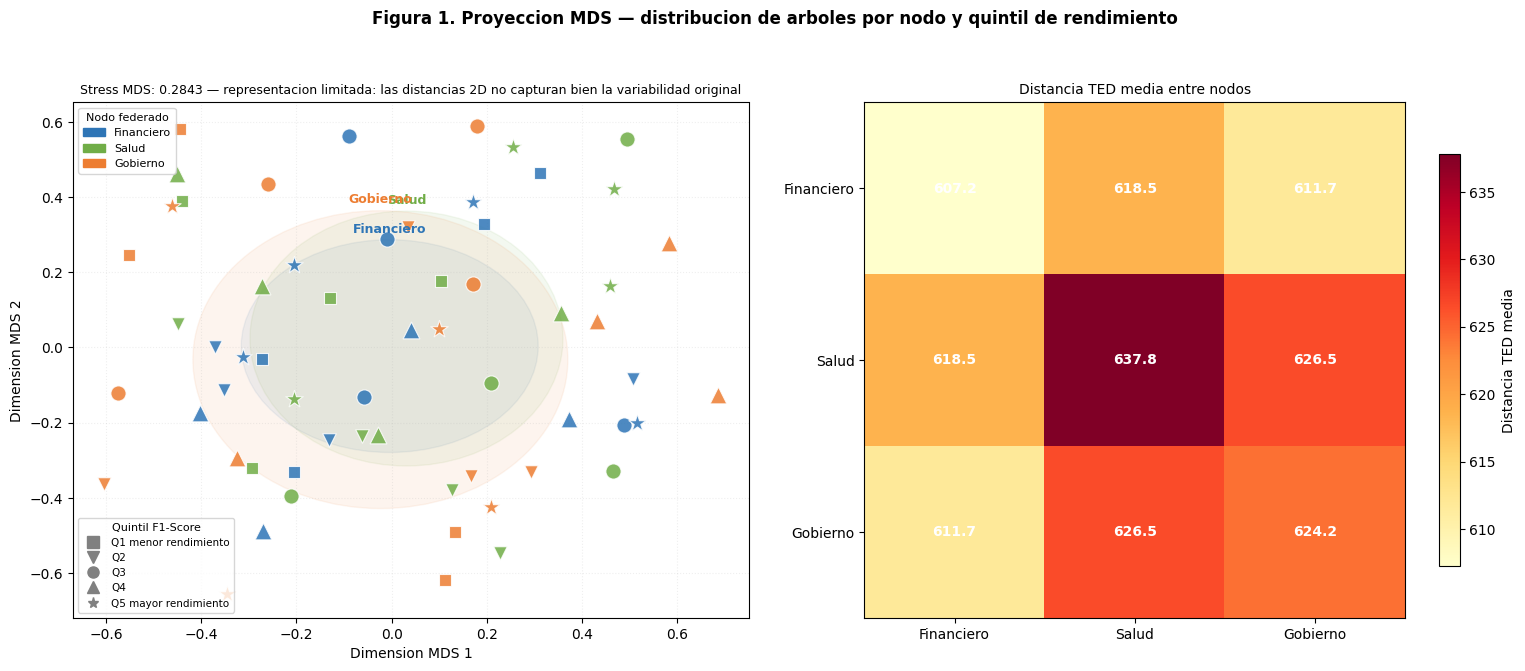

[ OK ] Figura 1 generada


In [6]:
print("Calculando proyeccion MDS...")
proyeccion_mds = MDS(
    n_components=2,
    dissimilarity="precomputed",
    metric=False,
    normalized_stress=True,
    random_state=SEMILLA,
    n_init=4,
    max_iter=500
)
coordenadas = proyeccion_mds.fit_transform(matriz_distancias)
stress_mds  = proyeccion_mds.stress_

interpretacion_stress = (
    "buena representacion"       if stress_mds < 0.10 else
    "representacion aceptable"   if stress_mds < 0.20 else
    "representacion limitada: las distancias 2D no capturan bien la variabilidad original"
)
print(f"  Stress MDS (normalizado): {stress_mds:.4f} — {interpretacion_stress}")
print()

tabla_vis = pd.DataFrame({
    "coord_x": coordenadas[:,0], "coord_y": coordenadas[:,1],
    "nodo": lista_nodos, "f1": lista_f1, "quintil": lista_quintiles
})

marcador_por_quintil = {0:"s", 1:"v", 2:"o", 3:"^", 4:"*"}
etiqueta_quintil     = {0:"Q1 menor rendimiento",1:"Q2",2:"Q3",3:"Q4",4:"Q5 mayor rendimiento"}
color_por_nodo       = {"Financiero":"#2E75B6","Salud":"#70AD47","Gobierno":"#ED7D31"}

fig, ejes = plt.subplots(1, 2, figsize=(16,7))
fig.suptitle("Figura 1. Proyeccion MDS — distribucion de arboles por nodo y quintil de rendimiento",
             fontsize=12, fontweight="bold")

eje_mds = ejes[0]
for nodo in nombres_nodos:
    for quintil, marcador in marcador_por_quintil.items():
        mascara = (tabla_vis["nodo"]==nodo) & (tabla_vis["quintil"]==quintil)
        sub     = tabla_vis[mascara]
        if len(sub) == 0: continue
        eje_mds.scatter(sub["coord_x"], sub["coord_y"],
                        c=color_por_nodo[nodo], marker=marcador,
                        s=70+quintil*25, alpha=0.85,
                        edgecolors="white", linewidths=0.8, zorder=3)

for nodo, color in color_por_nodo.items():
    sub = tabla_vis[tabla_vis["nodo"]==nodo]
    if len(sub) < 3: continue
    cx, cy = sub["coord_x"].mean(), sub["coord_y"].mean()
    sx, sy = max(sub["coord_x"].std()*2, 0.01), max(sub["coord_y"].std()*2, 0.01)
    eje_mds.add_patch(Ellipse((cx,cy), sx, sy, color=color, alpha=0.08, zorder=1))
    eje_mds.text(cx, cy+sy/2+0.02, nodo, ha="center", fontsize=9,
                 color=color, fontweight="bold")

leg1 = eje_mds.legend(
    handles=[mpatches.Patch(color=c, label=n) for n,c in color_por_nodo.items()],
    loc="upper left", fontsize=8, title="Nodo federado", title_fontsize=8)
eje_mds.add_artist(leg1)
eje_mds.legend(
    handles=[plt.Line2D([0],[0], marker=marcador_por_quintil[q], color="gray",
             markersize=8, linestyle="None", label=etiqueta_quintil[q]) for q in range(5)],
    loc="lower left", fontsize=7.5, title="Quintil F1-Score", title_fontsize=8)
eje_mds.set_xlabel("Dimension MDS 1", fontsize=10)
eje_mds.set_ylabel("Dimension MDS 2", fontsize=10)
eje_mds.set_title("Stress MDS: " + f"{stress_mds:.4f} — {interpretacion_stress}", fontsize=9)
eje_mds.grid(True, alpha=0.2, linestyle=":")

eje_calor = ejes[1]
num_nodos_lista   = len(nombres_nodos)
matriz_media_nodo = np.zeros((num_nodos_lista, num_nodos_lista))
for ii, n1 in enumerate(nombres_nodos):
    for jj, n2 in enumerate(nombres_nodos):
        idx1 = [k for k,v in enumerate(lista_nodos) if v==n1]
        idx2 = [k for k,v in enumerate(lista_nodos) if v==n2]
        vals = [matriz_distancias[a,b] for a in idx1 for b in idx2 if a!=b]
        matriz_media_nodo[ii,jj] = np.mean(vals) if vals else 0

im = eje_calor.imshow(matriz_media_nodo, cmap="YlOrRd", aspect="auto")
plt.colorbar(im, ax=eje_calor, label="Distancia TED media", shrink=0.8)
eje_calor.set_xticks(range(num_nodos_lista))
eje_calor.set_yticks(range(num_nodos_lista))
eje_calor.set_xticklabels(nombres_nodos, fontsize=10)
eje_calor.set_yticklabels(nombres_nodos, fontsize=10)
eje_calor.set_title("Distancia TED media entre nodos", fontsize=10)
for ii in range(num_nodos_lista):
    for jj in range(num_nodos_lista):
        color_txt = "white" if matriz_media_nodo[ii,jj] > matriz_media_nodo.max()*0.6 else "black"
        eje_calor.text(jj, ii, f"{matriz_media_nodo[ii,jj]:.1f}",
                       ha="center", va="center", fontsize=10,
                       fontweight="bold", color=color_txt)

plt.tight_layout(pad=2.5)
plt.savefig("resultados_ted/mds_ted_arboles.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()
print("[ OK ] Figura 1 generada")

---
## Seccion 6 — Analisis de patrones

In [7]:
print("=" * 54)
print("  ANALISIS DE COHESION ESTRUCTURAL POR NODO")
print("=" * 54)
print()

ratio_por_nodo = {}
for ii, nodo in enumerate(nombres_nodos):
    dist_intra  = matriz_media_nodo[ii,ii]
    dist_inter  = np.mean([matriz_media_nodo[ii,jj] for jj in range(num_nodos_lista) if jj!=ii])
    ratio       = dist_inter / dist_intra if dist_intra > 0 else float("inf")
    ratio_por_nodo[nodo] = ratio
    lectura = (
        "arboles del nodo son mas similares entre si que con otros nodos" if ratio > 1.2 else
        "variabilidad intra-nodo comparable a la inter-nodo"
    )
    print(f"  {nodo}:")
    print(f"    Dist. intra-nodo : {dist_intra:.1f}")
    print(f"    Dist. inter-nodo : {dist_inter:.1f}")
    print(f"    Ratio inter/intra: {ratio:.2f} — {lectura}")
    print()

corr_dim1, p_dim1 = spearmanr(tabla_vis["f1"], tabla_vis["coord_x"])
corr_dim2, p_dim2 = spearmanr(tabla_vis["f1"], tabla_vis["coord_y"])
print(f"  Correlacion F1 con MDS-1: rho={corr_dim1:.3f} (p={p_dim1:.3f})")
print(f"  Correlacion F1 con MDS-2: rho={corr_dim2:.3f} (p={p_dim2:.3f})")
print()
print("[ OK ] Analisis completado")

  ANALISIS DE COHESION ESTRUCTURAL POR NODO

  Financiero:
    Dist. intra-nodo : 607.2
    Dist. inter-nodo : 615.1
    Ratio inter/intra: 1.01 — variabilidad intra-nodo comparable a la inter-nodo

  Salud:
    Dist. intra-nodo : 637.8
    Dist. inter-nodo : 622.5
    Ratio inter/intra: 0.98 — variabilidad intra-nodo comparable a la inter-nodo

  Gobierno:
    Dist. intra-nodo : 624.2
    Dist. inter-nodo : 619.1
    Ratio inter/intra: 0.99 — variabilidad intra-nodo comparable a la inter-nodo

  Correlacion F1 con MDS-1: rho=0.205 (p=0.115)
  Correlacion F1 con MDS-2: rho=0.079 (p=0.547)

[ OK ] Analisis completado


---
## Conclusiones

In [8]:
# Conclusiones generadas automaticamente en funcion de los resultados obtenidos

nodo_cohesivo  = min(ratio_por_nodo, key=ratio_por_nodo.get)
ratio_cohesivo = ratio_por_nodo[nodo_cohesivo]
ratio_medio    = sum(ratio_por_nodo.values()) / len(ratio_por_nodo)
hay_correlacion = abs(corr_dim1) > 0.3 or abs(corr_dim2) > 0.3

# Interpretacion stress
if stress_mds < 0.10:
    txt_stress = (
        f"El Stress normalizado obtenido fue {stress_mds:.4f}, valor que indica "
        "buena fidelidad de la representacion bidimensional. Los patrones visuales "
        "de la Figura 1 son confiables para extraer conclusiones."
    )
elif stress_mds < 0.20:
    txt_stress = (
        f"El Stress normalizado obtenido fue {stress_mds:.4f}, dentro del rango "
        "aceptable. La proyeccion preserva las distancias originales con distorsion "
        "moderada. Los patrones visuales de la Figura 1 son orientativos."
    )
else:
    txt_stress = (
        f"El Stress normalizado obtenido fue {stress_mds:.4f}, valor que supera el "
        "umbral aceptable de 0.20. La distancia TED media global de "
        f"{matriz_distancias[matriz_distancias>0].mean():.1f} unidades refleja una "
        "diversidad estructural que dos dimensiones no comprimen sin distorsion "
        "significativa. Los patrones de la Figura 1 deben interpretarse con cautela."
    )

# Interpretacion cohesion
if ratio_medio > 1.2:
    txt_cohesion = (
        f"Los arboles forman grupos estructuralmente coherentes por nodo. "
        f"El nodo con mayor cohesion fue {nodo_cohesivo} "
        f"(ratio inter/intra: {ratio_cohesivo:.2f}). Cada sector desarrollo "
        "logicas de decision diferenciadas, esperable si los perfiles de amenaza difieren."
    )
else:
    txt_cohesion = (
        f"Los tres nodos presentan ratios inter/intra proximos a 1.0 "
        f"(mayor cohesion: {nodo_cohesivo}, ratio {ratio_cohesivo:.2f}). "
        "Los arboles no forman grupos coherentes por nodo de origen. "
        "Conocer la procedencia de un arbol no predice su estructura."
    )

# Interpretacion correlacion
if hay_correlacion:
    dim = "MDS-1" if abs(corr_dim1) > abs(corr_dim2) else "MDS-2"
    val = corr_dim1 if abs(corr_dim1) > abs(corr_dim2) else corr_dim2
    txt_correlacion = (
        f"Se observa correlacion moderada entre F1-Score y la dimension {dim} "
        f"(rho={val:.3f}). Los arboles de mayor rendimiento tienden a concentrarse "
        "en regiones diferenciadas del plano."
    )
    txt_implicacion = (
        "Existe una base para explorar ponderacion en la agregacion segun posicion MDS."
    )
else:
    txt_correlacion = (
        f"No se observa correlacion significativa entre F1-Score y posicion en el plano "
        f"(MDS-1: rho={corr_dim1:.3f}, MDS-2: rho={corr_dim2:.3f}). "
        "Estructura y rendimiento son dimensiones independientes en esta muestra."
    )
    txt_implicacion = (
        "No se identifica patron espacial que justifique ponderacion basada en posicion MDS. "
        "Esa conclusion tiene valor propio: descarta una hipotesis razonable con evidencia empirica."
    )

# Linea abierta
if stress_mds >= 0.20:
    txt_linea = (
        "La limitacion principal es dimensional: MDS en dos componentes es insuficiente "
        "para esta densidad estructural. Una extension natural seria aplicar t-SNE o UMAP, "
        "que preservan mejor la estructura local de distribuciones de alta variabilidad."
    )
else:
    txt_linea = (
        "Con la calidad de representacion obtenida, el siguiente paso natural seria "
        "disenar un mecanismo de agregacion ponderada en el que el peso de cada arbol "
        "dependa de su posicion en el espacio TED-MDS."
    )

sep = "=" * 62
print()
print(sep)
print("  CONCLUSIONES — EJD-UMA-002 v1.0")
print(sep)
print()
print("Sobre la proyeccion MDS:")
print(f"  {txt_stress}")
print()
print("Sobre la cohesion por nodo de origen:")
print(f"  {txt_cohesion}")
print()
print("Sobre la correlacion rendimiento-posicion:")
print(f"  {txt_correlacion}")
print()
print("Implicacion para el mecanismo de agregacion:")
print(f"  {txt_implicacion}")
print()
print("Linea abierta para investigacion doctoral:")
print(f"  {txt_linea}")
print()
print(sep)


  CONCLUSIONES — EJD-UMA-002 v1.0

Sobre la proyeccion MDS:
  El Stress normalizado obtenido fue 0.2843, valor que supera el umbral aceptable de 0.20. La distancia TED media global de 620.3 unidades refleja una diversidad estructural que dos dimensiones no comprimen sin distorsion significativa. Los patrones de la Figura 1 deben interpretarse con cautela.

Sobre la cohesion por nodo de origen:
  Los tres nodos presentan ratios inter/intra proximos a 1.0 (mayor cohesion: Salud, ratio 0.98). Los arboles no forman grupos coherentes por nodo de origen. Conocer la procedencia de un arbol no predice su estructura.

Sobre la correlacion rendimiento-posicion:
  No se observa correlacion significativa entre F1-Score y posicion en el plano (MDS-1: rho=0.205, MDS-2: rho=0.079). Estructura y rendimiento son dimensiones independientes en esta muestra.

Implicacion para el mecanismo de agregacion:
  No se identifica patron espacial que justifique ponderacion basada en posicion MDS. Esa conclusion t

In [9]:
import os

bloques = {
    "Entorno listo"        : "zss" in dir() and "np" in dir(),
    "Datos cargados"       : "datos_brutos" in dir(),
    "Arboles entrenados"   : "datos_por_nodo" in dir(),
    "Arboles convertidos"  : "lista_arboles_zss" in dir(),
    "Matriz TED calculada" : "matriz_distancias" in dir(),
    "Proyeccion MDS"       : "coordenadas" in dir(),
    "Figura generada"      : os.path.exists("resultados_ted/mds_ted_arboles.png"),
    "Analisis completado"  : "ratio_por_nodo" in dir(),
    "Conclusiones"         : "txt_stress" in dir(),
}

ok  = sum(bloques.values())
pct = int(ok / len(bloques) * 100)

print()
print("=" * 52)
print("  RESUMEN DE EJECUCION — EJD-UMA-002 v1.0")
print("=" * 52)
for nombre, estado in bloques.items():
    print(f"  [{'OK' if estado else 'XX'}]  {nombre}")
print("-" * 52)
if pct == 100:
    print(f"  Estado : {pct}% — Ejecucion completa")
    print()
    print(f"  Arboles analizados    : {len(lista_arboles_zss)}")
    print(f"  Pares TED calculados  : {len(lista_arboles_zss)*(len(lista_arboles_zss)-1)//2:,}")
    print(f"  Stress MDS norm.      : {stress_mds:.4f} — {interpretacion_stress}")
    print(f"  Dist. TED media global: {matriz_distancias[matriz_distancias>0].mean():.1f}")
    print(f"  Nodo mayor cohesion   : {min(ratio_por_nodo, key=ratio_por_nodo.get)} (ratio {min(ratio_por_nodo.values()):.2f})")
else:
    pendientes = [n for n,e in bloques.items() if not e]
    print(f"  Estado : {pct}% — Pendiente: {', '.join(pendientes)}")
print("=" * 52)
print()
print("  EH · M.Sc. Inteligencia Artificial — VIU Espana")
print("  EJD-UMA-002 v1.0 — Universidad de Malaga — Marzo 2026")


  RESUMEN DE EJECUCION — EJD-UMA-002 v1.0
  [OK]  Entorno listo
  [OK]  Datos cargados
  [OK]  Arboles entrenados
  [OK]  Arboles convertidos
  [OK]  Matriz TED calculada
  [OK]  Proyeccion MDS
  [OK]  Figura generada
  [OK]  Analisis completado
  [OK]  Conclusiones
----------------------------------------------------
  Estado : 100% — Ejecucion completa

  Arboles analizados    : 60
  Pares TED calculados  : 1,770
  Stress MDS norm.      : 0.2843 — representacion limitada: las distancias 2D no capturan bien la variabilidad original
  Dist. TED media global: 620.3
  Nodo mayor cohesion   : Salud (ratio 0.98)

  EH · M.Sc. Inteligencia Artificial — VIU Espana
  EJD-UMA-002 v1.0 — Universidad de Malaga — Marzo 2026
